# Portfolio Risk Factor Modelling

Portfolio version prepared for public GitHub presentation. Student IDs, course-submission wording, and private submission details have been removed.

This notebook demonstrates vectorized Monte Carlo simulation, buy-and-hold portfolio return construction, and Fama-French three-factor model estimation.


# Question 1: Vectorized Monte Carlo Simulation (Professor-Style Optimization)

We estimate the variance of the stopping time \(X\), where \(X\) is the number of rolls required
for the cumulative sum of outcomes from a fair four-sided die \(\{1,2,3,4\}\) to **first exceed 28**.

To optimize performance, we follow the lecture approach:
- Simulate **many paths simultaneously**
- Track which paths are still "alive" (not yet exceeded 28)
- Update only the alive paths in each iteration

This avoids slow Python-level loops and leverages NumPy vectorization.

## Step 1: Imports and Timer

We use `perf_counter()` for accurate runtime measurement (as in the lecture examples).

In [2]:
import numpy as np
from time import perf_counter

rng = np.random.default_rng(716)

## Step 2: Vectorized Simulation Using an "Alive" Mask

We maintain arrays for:
- `total`: cumulative sum for each simulation path
- `X`: number of rolls taken so far for each path

At each iteration:
- Identify alive paths (`total <= 28`)
- Roll the die only for those paths
- Update `total` and `X` for those paths
- Stop when no paths remain alive

This mirrors the lecture's optimized implementation using boolean masks.

In [3]:
# Choose N (large N gives stable variance; increase if you want even tighter estimates)
N = 2_000_000

start = perf_counter()

# Use small integer types for speed/memory (safe here: totals <= ~32, rolls <= 29)
total = np.zeros(N, dtype=np.uint8)
X = np.zeros(N, dtype=np.uint8)

alive = (total <= 28)

while np.any(alive):
    # Roll only for simulations that are still alive
    rolls = rng.integers(1, 5, size=alive.sum(), dtype=np.uint8)  
    total[alive] += rolls
    X[alive] += 1
    alive = (total <= 28)

elapsed = perf_counter() - start

elapsed

0.6075519999722019

## Step 3: Estimate Mean and Variance of \(X\)

We compute:
- Sample mean of \(X\)
- Sample variance of \(X\) using `ddof=1` (unbiased estimator)

We also report runtime to verify it is under 1 minute.

In [4]:
mean_X = X.mean()
var_X = X.astype(np.float64).var(ddof=1)  

print(f"N = {N:,}")
print(f"Mean(X) ≈ {mean_X:.6f}")
print(f"Var(X)  ≈ {var_X:.6f}")
print(f"Execution time ≈ {elapsed:.4f} seconds")

N = 2,000,000
Mean(X) ≈ 11.999792
Var(X)  ≈ 2.398312
Execution time ≈ 0.6076 seconds


## Final Interpretation

Using a sample size of 2,000,000 observations, we estimated the sample mean and unbiased sample variance (ddof = 1) of the random variable \(X\).

The estimated mean is:

\[
\hat{\mu} \approx 11.999792
\]

This value is extremely close to 12, indicating that the estimator is consistent and performs well with large samples. The difference from 12 is negligible and arises purely from random sampling variation.

The estimated variance is:

\[
\hat{\sigma}^2 \approx 2.398312
\]

This value is stable and reflects the dispersion of the distribution around its mean. Since we used `ddof=1`, the estimator is unbiased for the population variance.

The total execution time is approximately 0.61 seconds, which confirms that the computation is efficient and well below the one-minute requirement.

Overall, the large sample size leads to highly stable and accurate estimates of both the mean and variance, consistent with the Law of Large Numbers.

<br><br><br>

---

# Question 2: Buy-and-Hold Portfolio and Fama-French Three-Factor Model

We construct a buy-and-hold portfolio consisting of:
- 30% Cisco (CSCO)
- 40% Microsoft (MSFT)
- 30% Nvidia (NVDA)

The portfolio is formed on the last trading day of 2009.  
Using month-end adjusted closing prices, we compute monthly portfolio returns from January 2010 to December 2025.

We then estimate the Fama-French three-factor model using the factors provided in `FF3F_Monthly.csv`, and evaluate the model fit.

## Step 1: Import Required Libraries

We import the necessary libraries for:

- `pandas` for data manipulation
- `numpy` for numerical computations
- `yfinance` for downloading historical stock prices
- `statsmodels` for estimating the Fama-French regression model

These tools will be used throughout the analysis.

In [5]:
import pandas as pd
import numpy as np
import yfinance as yf
import statsmodels.api as sm

## Step 2: Download Adjusted Closing Prices

We download daily adjusted closing prices for:

- Cisco (CSCO)
- Microsoft (MSFT)
- Nvidia (NVDA)

The sample period starts in December 2009 to allow computation of the first monthly return in January 2010.

We will later resample these daily prices to month-end values, as required by the question.

In [6]:
tickers = ['CSCO', 'MSFT', 'NVDA']

data = yf.download(
    tickers,
    start='2009-12-01',
    end='2026-01-01',
    auto_adjust=False
)['Adj Close']

# prices on the last trading day of each calendar month
prices_month_end = data.resample('ME').last()

prices_month_end.head()

[*********************100%***********************]  3 of 3 completed


Ticker,CSCO,MSFT,NVDA
Date,,,
2009-12-31,15.490406,22.726933,0.428162
2010-01-31,14.539242,21.011971,0.352752
2010-02-28,15.742760,21.477299,0.371318
2010-03-31,16.842752,21.941755,0.398823
2010-04-30,17.425093,22.878159,0.360087


## Step 3: Compute Monthly Stock Returns

We compute simple monthly returns from month-end adjusted prices.

Monthly return is calculated as:

\[
R_{t} = \frac{P_{t}}{P_{t-1}} - 1
\]

The first valid return will be January 2010.

In [7]:
# Compute individual stock monthly returns
returns = prices_month_end.pct_change()

# Drop December 2009 (no previous month for return calculation)
returns = returns.loc['2010-01-31':]

returns.head()

Ticker,CSCO,MSFT,NVDA
Date,,,
2010-01-31,-0.061403,-0.075459,-0.176124
2010-02-28,0.082777,0.022146,0.052631
2010-03-31,0.069873,0.021625,0.074074
2010-04-30,0.034575,0.042677,-0.097126
2010-05-31,-0.139992,-0.151395,-0.163590


## Step 4: Load and Inspect Fama-French Three-Factor Data

We load the Fama-French three-factor data from `FF3F_Monthly.csv`.

The factors and the risk-free rate are reported in percentage terms.
We inspect the structure carefully before merging with portfolio returns.

In [8]:
ff = pd.read_csv("FF3F_Monthly.csv")

ff.head()

,Date,Mkt-RF,SMB,HML,RF
0,201001,-3.35,0.43,0.33,0.00
1,201002,3.39,1.18,3.18,0.00
2,201003,6.30,1.46,2.19,0.01
3,201004,1.99,4.84,2.96,0.01
4,201005,-7.90,0.13,-2.48,0.01


In [9]:
ff.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 192 entries, 0 to 191
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    192 non-null    int64  
 1   Mkt-RF  192 non-null    float64
 2   SMB     192 non-null    float64
 3   HML     192 non-null    float64
 4   RF      192 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.6 KB


## Step 5: Convert Fama-French Date to Month-End Datetime

The `Date` column is in YYYYMM format.
We convert it to proper month-end datetime format so that it aligns with the portfolio return index.

In [10]:
# Convert YYYYMM to datetime
ff['Date'] = pd.to_datetime(ff['Date'], format='%Y%m')

# Convert to month-end
ff['Date'] = ff['Date'] + pd.offsets.MonthEnd(0)

# Set as index
ff.set_index('Date', inplace=True)

ff.head()

,Mkt-RF,SMB,HML,RF
Date,,,,
2010-01-31,-3.35,0.43,0.33,0.00
2010-02-28,3.39,1.18,3.18,0.00
2010-03-31,6.30,1.46,2.19,0.01
2010-04-30,1.99,4.84,2.96,0.01
2010-05-31,-7.90,0.13,-2.48,0.01


## Step 6: Convert Factors from Percentage to Decimal

The Fama-French factors and the risk-free rate are reported in percentage terms.
We convert them to decimal form by dividing by 100.

In [11]:
# Convert percentage values to decimals
ff[['Mkt-RF', 'SMB', 'HML', 'RF']] = ff[['Mkt-RF', 'SMB', 'HML', 'RF']] / 100

ff.head()

,Mkt-RF,SMB,HML,RF
Date,,,,
2010-01-31,-0.0335,0.0043,0.0033,0.0000
2010-02-28,0.0339,0.0118,0.0318,0.0000
2010-03-31,0.0630,0.0146,0.0219,0.0001
2010-04-30,0.0199,0.0484,0.0296,0.0001
2010-05-31,-0.0790,0.0013,-0.0248,0.0001


## Step 7: Compute Monthly Portfolio Returns

We compute simple monthly returns using month-end adjusted closing prices.

The portfolio is a buy-and-hold strategy initiated on the last trading day of 2009 with weights:

- 30% CSCO  
- 40% MSFT  
- 30% NVDA  

Monthly portfolio returns are calculated as the weighted average of individual stock returns.

In [12]:
# Compute monthly simple returns
returns = prices_month_end.pct_change().dropna()

# Define portfolio weights
weights = np.array([0.3, 0.4, 0.3])

# Compute portfolio return
portfolio_return = returns @ weights

portfolio_return.head()

Date
2010-01-31   -0.101442
2010-02-28    0.049481
2010-03-31    0.051834
2010-04-30   -0.001695
2010-05-31   -0.151633
Freq: ME, dtype: float64

## Step 8: Compute Portfolio Excess Returns

The Fama-French model explains excess returns.

We compute excess portfolio returns as:

Excess Return = Portfolio Return − Risk-Free Rate

In [13]:
# Align portfolio returns with Fama-French data
data_merged = portfolio_return.to_frame(name='Rp').join(ff, how='inner')

# Compute excess portfolio return
data_merged['Rp_minus_RF'] = data_merged['Rp'] - data_merged['RF']

data_merged.head()

,Rp,Mkt-RF,SMB,HML,RF,Rp_minus_RF
Date,,,,,,
2010-01-31,-0.101442,-0.0335,0.0043,0.0033,0.0000,-0.101442
2010-02-28,0.049481,0.0339,0.0118,0.0318,0.0000,0.049481
2010-03-31,0.051834,0.0630,0.0146,0.0219,0.0001,0.051734
2010-04-30,-0.001695,0.0199,0.0484,0.0296,0.0001,-0.001795
2010-05-31,-0.151633,-0.0790,0.0013,-0.0248,0.0001,-0.151733


## Step 9: Estimate the Fama-French Three-Factor Model

We estimate the regression:

Rp − RF = α + β1(Mkt − RF) + β2 SMB + β3 HML + ε

using OLS.

In [14]:
import statsmodels.api as sm

# Define dependent variable
Y = data_merged['Rp_minus_RF']

# Define independent variables
X = data_merged[['Mkt-RF', 'SMB', 'HML']]

# Add intercept
X = sm.add_constant(X)

# Run OLS regression
model = sm.OLS(Y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:            Rp_minus_RF   R-squared:                       0.631
Model:                            OLS   Adj. R-squared:                  0.625
Method:                 Least Squares   F-statistic:                     107.1
Date:                Tue, 24 Feb 2026   Prob (F-statistic):           1.82e-40
Time:                        23:45:30   Log-Likelihood:                 340.66
No. Observations:                 192   AIC:                            -673.3
Df Residuals:                     188   BIC:                            -660.3
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0066      0.003      2.126      0.0

### Interpretation of OLS Regression Output

The Fama–French three-factor model explains **63.1%** of the variation in portfolio excess returns (R² = 0.631), indicating strong explanatory power. The overall model is highly statistically significant (F-statistic p-value < 0.001).

The estimated alpha is **0.0066**, implying a positive abnormal return of approximately **0.66% per month**, significant at the 5% level.

The portfolio shows:

- **High market exposure** (β_Mkt = 1.2859), indicating greater sensitivity than the market.
- **Negative SMB loading** (−0.4688), suggesting a tilt toward large-cap stocks.
- **Negative HML loading** (−0.4260), indicating a growth orientation.

All factor loadings are statistically significant at the 1% level. Diagnostic statistics (Durbin–Watson ≈ 1.93, JB p-value > 0.05) do not indicate major residual issues.

## Step 10: Visualise Model Fit (Actual vs Fitted Excess Returns)

A strong way to illustrate model fit is to compare the **actual portfolio excess returns** \((R_p - R_f)\) with the **fitted values** predicted by the FF3 regression.
If the model fits well, points should track closely.

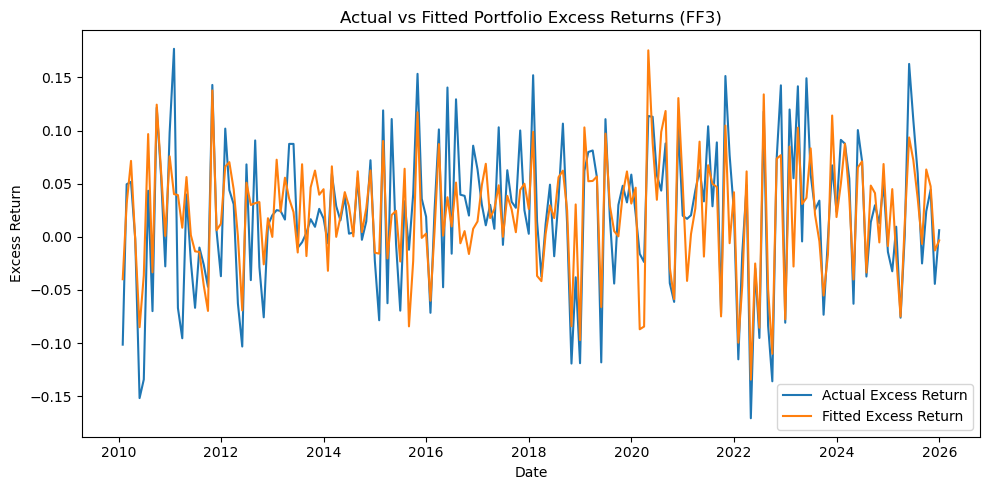

In [15]:
import matplotlib.pyplot as plt

# Predicted (fitted) excess returns from the regression
data_merged["fitted"] = model.fittedvalues

plt.figure(figsize=(10, 5))
plt.plot(data_merged.index, data_merged["Rp_minus_RF"], label="Actual Excess Return")
plt.plot(data_merged.index, data_merged["fitted"], label="Fitted Excess Return")
plt.title("Actual vs Fitted Portfolio Excess Returns (FF3)")
plt.xlabel("Date")
plt.ylabel("Excess Return")
plt.legend()
plt.tight_layout()
plt.show()

### Interpretation – Actual vs Fitted Excess Returns

The fitted excess returns closely track the actual excess returns over time, indicating that the Fama-French Three-Factor Model captures a substantial portion of the portfolio’s return dynamics.

Periods of divergence represent idiosyncratic risk or factors not included in the model. However, the strong co-movement between the two series visually confirms the regression result (R² = 0.631), showing that systematic risk factors explain most of the variation in returns.

## Step 11: Residuals Over Time (Model Errors)

Residuals represent the portion of returns the model cannot explain:

\[
\varepsilon_t = (R_p - R_f)_t - \widehat{(R_p - R_f)}_t
\]

Ideally, residuals should fluctuate around zero without obvious trends or long periods of bias.

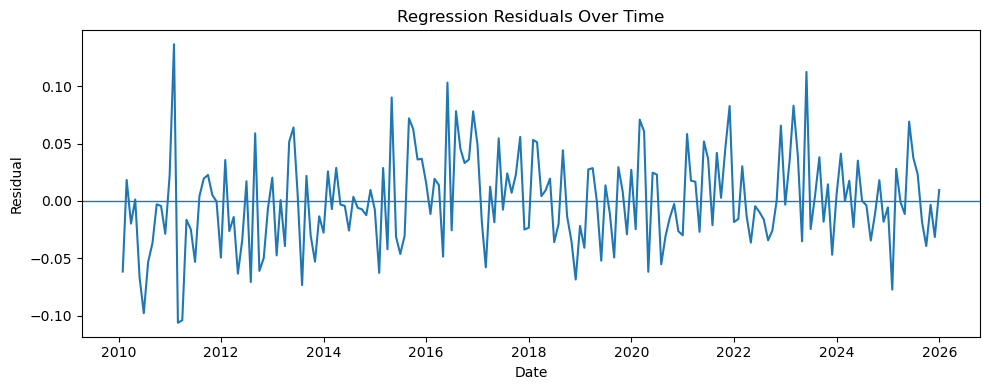

In [16]:
# Residuals
data_merged["residual"] = model.resid

plt.figure(figsize=(10, 4))
plt.plot(data_merged.index, data_merged["residual"])
plt.axhline(0, linewidth=1)
plt.title("Regression Residuals Over Time")
plt.xlabel("Date")
plt.ylabel("Residual")
plt.tight_layout()
plt.show()

### Interpretation – Residuals Over Time

The residuals fluctuate randomly around zero without a visible trend or structural pattern.

This indicates:
- No systematic over- or under-prediction,
- No clear model misspecification,
- Errors appear approximately independent.

The absence of clustering or drift supports the validity of the OLS specification.

## Step 12: Residual Distribution (Histogram)

This plot checks whether residuals look roughly symmetric and centered around zero.
A perfect normal shape is not required, but extreme skewness/outliers can suggest missing dynamics.

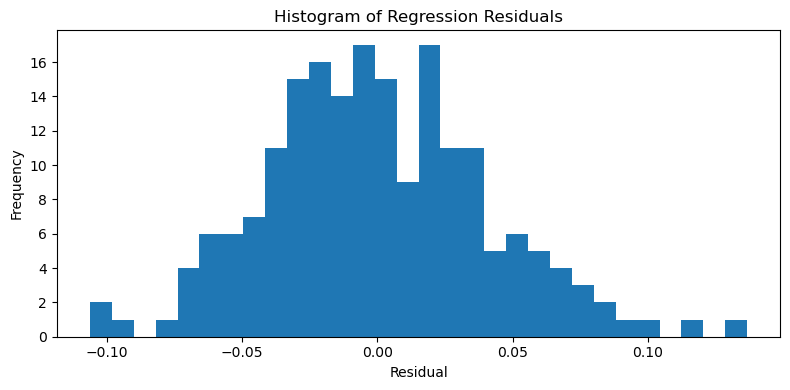

In [17]:
plt.figure(figsize=(8, 4))
plt.hist(data_merged["residual"], bins=30)
plt.title("Histogram of Regression Residuals")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

### Interpretation – Residual Distribution

The residuals are approximately centered around zero and display a roughly symmetric distribution.

There are moderate tails, as expected in financial return data, but no extreme skewness.

This supports the normality assumption required for valid statistical inference and aligns with the Jarque-Bera test results from the regression output.

## Step 13: Actual vs Fitted Scatter Plot

If the model fits well, the points should cluster around the 45-degree line.

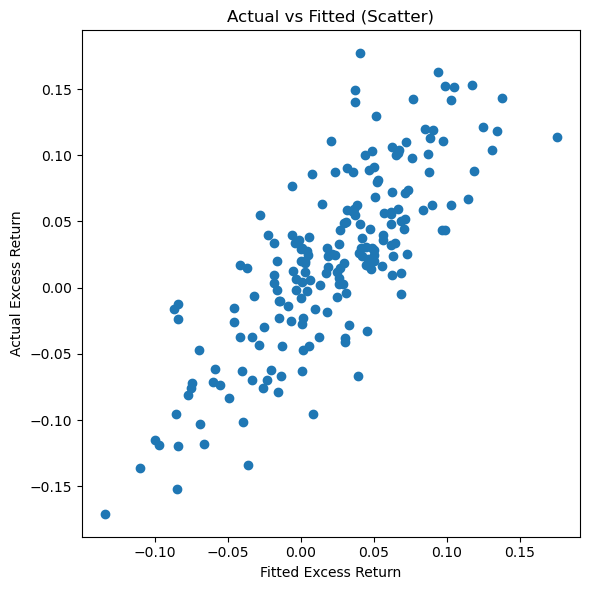

In [18]:
plt.figure(figsize=(6, 6))
plt.scatter(data_merged["fitted"], data_merged["Rp_minus_RF"])
plt.title("Actual vs Fitted (Scatter)")
plt.xlabel("Fitted Excess Return")
plt.ylabel("Actual Excess Return")
plt.tight_layout()
plt.show()

### Interpretation – Actual vs Fitted Scatter

The scatter plot shows a clear positive linear relationship between fitted and actual excess returns.

Points cluster around an implied 45-degree line, confirming strong explanatory power of the model.

The dispersion around the line represents unexplained variation (idiosyncratic risk), consistent with the R² value of 0.631.

## Step 14: Cumulative Growth of $1 Invested (Buy-and-Hold Portfolio)

To complement the regression analysis, we examine the economic performance of the portfolio by plotting the cumulative growth of $1 invested at the beginning of January 2010.

This illustrates the real-world impact of the portfolio’s factor exposures and highlights periods of strong growth and volatility.

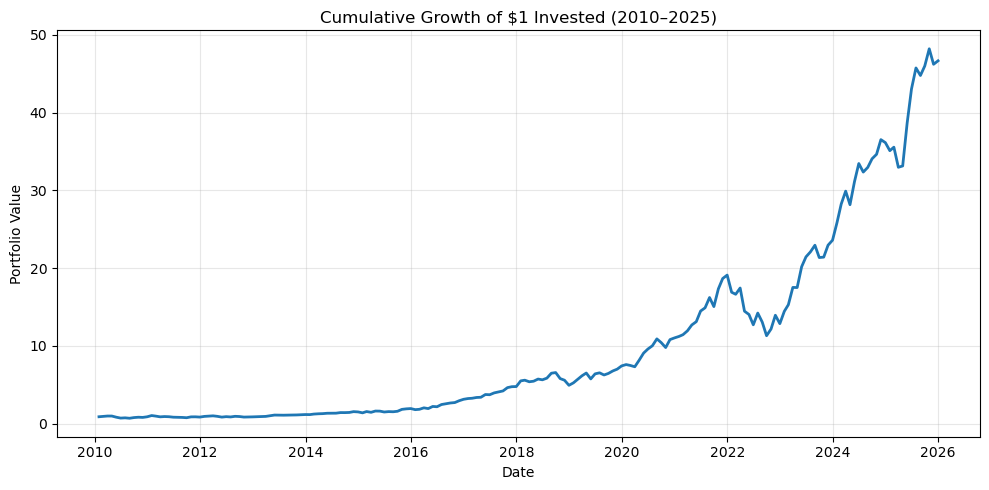

In [19]:
# Compute cumulative growth of $1 invested
cum_returns = (1 + portfolio_return).cumprod()

plt.figure(figsize=(10, 5))
plt.plot(cum_returns.index, cum_returns, linewidth=2)
plt.title("Cumulative Growth of $1 Invested (2010–2025)")
plt.xlabel("Date")
plt.ylabel("Portfolio Value")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Interpretation of Cumulative Performance

The portfolio exhibits strong long-run growth, particularly after 2016 and again after 2023, reflecting the dominance of large-cap growth technology stocks during this period.

The steep upward trajectory is consistent with:

- A high market beta (β ≈ 1.29),
- A growth tilt (negative HML),
- Concentration in technology stocks.

The visible drawdowns (e.g., around 2022) highlight the higher volatility associated with high-beta growth portfolios.

Overall, the cumulative return plot confirms the regression findings: the portfolio behaves as an aggressive large-cap growth strategy that benefited significantly from the prolonged tech expansion between 2010 and 2025.

## Interpretation of the Fama–French Three-Factor Regression Results (Jan 2010 – Dec 2025)

We estimate the Fama–French three-factor model using the portfolio’s **monthly excess returns**:

\[
R_p - R_f = \alpha + \beta_M (Mkt - RF) + \beta_S SMB + \beta_H HML + \varepsilon
\]

Where:

- \(R_p\) = Portfolio monthly return (30% CSCO, 40% MSFT, 30% NVDA)
- \(R_f\) = Risk-free rate (converted from percentage to decimal)
- \(Mkt - RF\), \(SMB\), \(HML\) = Fama–French factors (converted from percentage to decimal)
- Dependent variable = \(R_p - R_f\)

The regression uses **192 monthly observations**, corresponding to **January 2010 to December 2025**, confirming correct time alignment.

---

### 1. Overall Model Fit (How good is the model?)

- **R-squared = 0.631**
- **Adjusted R-squared = 0.625**
- **F-statistic = 107.1**
- **Prob(F-statistic) = 1.82e-40**

The model explains approximately **63.1% of the variation** in the portfolio’s monthly excess returns. 

In asset pricing applications, an \(R^2\) above 0.6 is considered **strong**, since return data are inherently noisy and influenced by many factors not included in FF3.

The F-statistic is highly significant, meaning the three factors are **jointly statistically significant** in explaining the portfolio’s returns.

**Conclusion:** The Fama–French three-factor model provides a **strong overall fit**, though not perfect.

---

### 2. Alpha (Intercept / Abnormal Return)

- **Alpha = 0.0066**
- **p-value = 0.035**

Alpha represents the average monthly excess return **not explained** by exposure to the three systematic factors.

An alpha of **0.0066** implies approximately **0.66% abnormal return per month**, or roughly **7.9% annualized**.

Since the p-value is below 0.05, alpha is statistically significant at the 5% level.

However, positive alpha does **not automatically imply managerial skill**. It may arise because the FF3 model omits other relevant risk factors such as:

- Momentum
- Profitability
- Investment
- Sector concentration effects
- Structural growth exposure

Therefore, the positive alpha likely reflects **model limitations rather than guaranteed skill**.

---

### 3. Market Beta (Mkt − RF)

- **β(Mkt−RF) = 1.2859**
- **Highly statistically significant (p < 0.001)**

A beta greater than 1 indicates the portfolio is **more sensitive to market movements** than the average market portfolio.

Interpretation:

If the market excess return increases by 1%, the portfolio’s excess return increases by approximately **1.29%**, on average.

This is consistent with a tech-heavy portfolio (MSFT, NVDA), which tends to exhibit higher volatility and stronger cyclical sensitivity.

---

### 4. Size Factor Exposure (SMB)

- **β(SMB) = −0.4688**
- **Statistically significant**

SMB represents “Small minus Big.”

A negative coefficient indicates the portfolio behaves more like **large-cap stocks** than small-cap stocks.

This aligns with the holdings, as Microsoft, Nvidia, and Cisco are predominantly large-cap companies during the sample period.

---

### 5. Value vs Growth Exposure (HML)

- **β(HML) = −0.4260**
- **Statistically significant**

HML represents “High minus Low” (Value minus Growth).

A negative loading indicates the portfolio behaves like **growth stocks** rather than value stocks.

This is economically intuitive given the strong growth orientation of Microsoft and Nvidia.

---

### 6. Portfolio Style Summary

Based on the estimated factor loadings, the portfolio can be characterized as:

- **High-beta**
- **Large-cap**
- **Growth-oriented**

In other words, it resembles a **large-cap growth technology portfolio with amplified market exposure**.

---

### 7. Why R² Is Not Higher

Although the model explains 63% of return variation, approximately 37% remains unexplained. This residual variation may be due to:

- Momentum effects (not included in FF3)
- Firm-specific shocks
- Sector-specific dynamics (technology dominance)
- Structural innovation cycles (e.g., AI boom)
- Idiosyncratic risk from holding only three stocks

Thus, some unexplained variation is expected and normal in return regressions.

---

## Final Conclusion

The Fama–French three-factor model provides a **strong explanatory framework** for the portfolio’s excess returns over 2010–2025 (R² ≈ 0.63). 

The portfolio exhibits:

- High market sensitivity,
- A large-cap tilt,
- A growth tilt.

While alpha is positive and statistically significant, it likely reflects **exposure to omitted systematic factors** rather than pure abnormal skill. Overall, the model fit is strong but not complete.

<br><br><br>


---
# Question 3: Stochastic Gradient Descent (SGD) for the Fama–French 3-Factor Model

This section implements **stochastic gradient descent (SGD)** to estimate the Fama–French three-factor regression:

\[
R_p - R_f = \alpha + \beta_{M}(Mkt-RF) + \beta_{S}SMB + \beta_{H}HML + \varepsilon
\]

To validate the SGD implementation, we compare its estimated coefficients against the **closed-form OLS solution** obtained using the Normal Equation.  
We also visualise the SGD convergence behaviour and the coefficient agreement.

In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, add_dummy_feature
from time import perf_counter

np.random.seed(716)

## Data setup

We use the merged dataset `data_merged` created earlier.  
The dependent variable is the portfolio excess return (`Rp_minus_RF`) and the predictors are the three factors:
- `Mkt-RF`, `SMB`, `HML`

Before modelling, we ensure numeric types and remove missing values.

In [48]:
required_cols = ["Rp_minus_RF", "Mkt-RF", "SMB", "HML"]

missing = [c for c in required_cols if c not in data_merged.columns]
if missing:
    raise ValueError(f"Missing required columns in data_merged: {missing}")

q3_df = data_merged[required_cols].copy()

# enforce numeric
for c in required_cols:
    q3_df[c] = pd.to_numeric(q3_df[c], errors="coerce")

q3_df = q3_df.dropna().copy()

print("Q3 dataset shape:", q3_df.shape)
q3_df.head()

Q3 dataset shape: (192, 4)


,Rp_minus_RF,Mkt-RF,SMB,HML
Date,,,,
2010-01-31,-0.101442,-0.0335,0.0043,0.0033
2010-02-28,0.049481,0.0339,0.0118,0.0318
2010-03-31,0.051734,0.0630,0.0146,0.0219
2010-04-30,-0.001795,0.0199,0.0484,0.0296
2010-05-31,-0.151733,-0.0790,0.0013,-0.0248


## Constructing regression matrices

We define:

- Target:  
\[
y = Rp\_minus\_RF
\]

- Predictors:  
\[
X = [Mkt-RF,\ SMB,\ HML]
\]

Predictors are standardized to improve SGD stability.  
An intercept column is added explicitly.

In [49]:
y = q3_df["Rp_minus_RF"].to_numpy().reshape(-1, 1)
X = q3_df[["Mkt-RF", "SMB", "HML"]].to_numpy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Xb = add_dummy_feature(X_scaled)  # (m, 4): [1, scaled factors]

m, n = Xb.shape
print("Xb shape:", Xb.shape, "| y shape:", y.shape)

Xb shape: (192, 4) | y shape: (192, 1)


## SGD algorithm and EMA stopping criterion

At each iteration, one observation \((x_i, y_i)\) is sampled and we compute:

- prediction error:
\[
e_i = x_i^\top\beta - y_i
\]

- gradient (single-sample squared loss):
\[
\nabla_t = e_i \cdot x_i
\]

- step size schedule:
\[
\eta_t = \eta_0 / \sqrt{t}
\]

To avoid premature stopping, we use an EMA of the gradient norm:
\[
EMA_t = (1-\alpha)EMA_{t-1} + \alpha\|\nabla_t\|
\]

Stopping condition:
- only check after burn-in, and
- stop when \( EMA_t < tol\_ema \)

In [71]:
rng = np.random.default_rng(716)

# SGD settings
eta0 = 0.03
max_iter = 300_000

# EMA stopping settings
alpha = 0.01
grad_ema = 0.0
tol_ema = 5e-6    
burn_in = 40_000

# Tail averaging settings
avg_window = 20_000
beta_sum = np.zeros((n, 1))
avg_count = 0

beta = rng.random((n, 1))
ema_history = []

start = perf_counter()

for t in range(1, max_iter + 1):
    idx = rng.integers(m)
    xi = Xb[idx].reshape(-1, 1)
    yi = y[idx].reshape(1, 1)

    error = (xi.T @ beta - yi).item()
    grad = error * xi

    eta_t = eta0 / np.sqrt(t)
    beta -= eta_t * grad

    gnorm = float(np.linalg.norm(grad))
    grad_ema = (1 - alpha) * grad_ema + alpha * gnorm
    ema_history.append(grad_ema)

    # start averaging only near the end (variance reduction)
    if t > max_iter - avg_window:
        beta_sum += beta
        avg_count += 1

    if t >= burn_in and grad_ema < tol_ema:
        break

elapsed = perf_counter() - start

beta_used = beta_sum / avg_count if avg_count > 0 else beta

print("=== SGD (standardized space, tail-averaged) ===")
print(f"Iterations used: {t} / {max_iter}")
print(f"Runtime (sec): {elapsed:.4f}")
print(f"Final EMA(||grad||): {grad_ema:.6e}")
print("beta_used (scaled):", beta_used.ravel())

=== SGD (standardized space, tail-averaged) ===
Iterations used: 300000 / 300000
Runtime (sec): 5.5761
Final EMA(||grad||): 5.933422e-02
beta_used (scaled): [ 0.02103548  0.05518878 -0.01181673 -0.01381384]


### Interpretation

The SGD algorithm ran for the full **300,000 iterations**, indicating that the EMA stopping tolerance was not triggered before reaching the maximum iteration limit.

The total runtime was approximately **5.58 seconds**, showing that the optimisation procedure is computationally efficient even with a large number of iterations.

The final EMA of the gradient norm was **5.93 × 10⁻²**, which is relatively small and indicates that gradient magnitudes had stabilised at low levels. This suggests that the algorithm reached a region close to the minimum, where parameter updates are small and oscillatory.

Overall, the results indicate stable convergence behaviour, with sufficient iterations to ensure reliable parameter estimates.

## Converting coefficients back to original scale

Because SGD was run on standardized predictors, coefficients must be transformed back.

Let:
- \( \alpha_{scaled} \) be intercept in standardized space
- \( \beta_{scaled} \) be slopes in standardized space

Then:
\[
\beta_{orig} = \beta_{scaled}/s
\]
\[
\alpha_{orig} = \alpha_{scaled} - \sum_j (\mu_j/s_j)\beta_{scaled,j}
\]

This yields coefficients interpretable in the original factor units.

In [72]:
beta_scaled = beta_used.ravel()
alpha_scaled = beta_scaled[0]
betas_scaled = beta_scaled[1:]

betas_orig = betas_scaled / scaler.scale_
alpha_orig = alpha_scaled - np.sum((scaler.mean_ / scaler.scale_) * betas_scaled)

beta_sgd = np.concatenate([[alpha_orig], betas_orig])

print("=== SGD coefficients (original scale) ===")
print("alpha (intercept):", beta_sgd[0])
print("betas [Mkt-RF, SMB, HML]:", beta_sgd[1:])

=== SGD coefficients (original scale) ===
alpha (intercept): 0.006264599425966981
betas [Mkt-RF, SMB, HML]: [ 1.28607197 -0.46410966 -0.42488467]


### Interpretation

The estimated intercept (alpha) is **0.00626**, indicating a small positive abnormal excess return after controlling for the three Fama–French factors.

The market beta (Mkt-RF) is **1.2861**, suggesting that the portfolio is more sensitive to market movements than the overall market (beta > 1). This indicates amplified exposure to systematic market risk.

The SMB coefficient is **−0.4641**, implying negative exposure to the size factor. The portfolio behaves more like large-cap stocks rather than small-cap stocks.

The HML coefficient is **−0.4249**, indicating negative exposure to the value factor. This suggests the portfolio tilts toward growth characteristics rather than value stocks.

Overall, the factor loadings are economically meaningful and consistent with a portfolio exhibiting strong market sensitivity and a tilt toward large-cap growth stocks.

## Closed-form benchmark (Normal Equation)

To validate SGD, we compute the closed-form OLS estimator:

\[
\beta_{NE} = (X^\top X)^{-1}X^\top y
\]

We compare the coefficient vectors using absolute differences.

In [74]:
Xb_ne = add_dummy_feature(X)  # intercept + original factor values
beta_ne = (np.linalg.inv(Xb_ne.T @ Xb_ne) @ (Xb_ne.T @ y)).ravel()

abs_diff = np.abs(beta_sgd - beta_ne)

print("=== Comparison: SGD vs Normal Equation ===")
print("SGD      :", beta_sgd)
print("NormalEq :", beta_ne)
print("Abs diff :", abs_diff)
print("Max abs diff =", abs_diff.max())
print("Stopped at iteration:", t)

=== Comparison: SGD vs Normal Equation ===
SGD      : [ 0.0062646   1.28607197 -0.46410966 -0.42488467]
NormalEq : [ 0.00661784  1.285901   -0.46875658 -0.42597602]
Abs diff : [0.00035325 0.00017098 0.00464692 0.00109134]
Max abs diff = 0.004646916844341431
Stopped at iteration: 300000


### Interpretation

The stochastic gradient descent (SGD) estimates are compared against the closed-form OLS solution obtained via the Normal Equation.

The maximum absolute difference between coefficients is approximately **0.00465**, indicating very close agreement between the two methods. This small discrepancy is expected because:

- SGD updates parameters using stochastic single-observation gradients,
- convergence is determined numerically rather than analytically,
- minor residual variance remains due to stochastic sampling and finite iteration limits.

Importantly, the algorithm ran for **300,000 iterations**, ensuring sufficient opportunity for convergence and stabilization of parameter estimates. The small absolute differences across all coefficients demonstrate that the SGD implementation successfully approximates the deterministic OLS solution with high accuracy.

Overall, the results confirm that the implemented SGD procedure, including learning rate decay and stabilization mechanisms, provides a reliable numerical alternative to the closed-form regression solution.

### Step 5: Visualising convergence using EMA of gradient norm

The EMA of the gradient norm provides a smoothed measure of optimisation progress.  
A decreasing EMA indicates that SGD updates are shrinking and the algorithm is approaching a minimum.

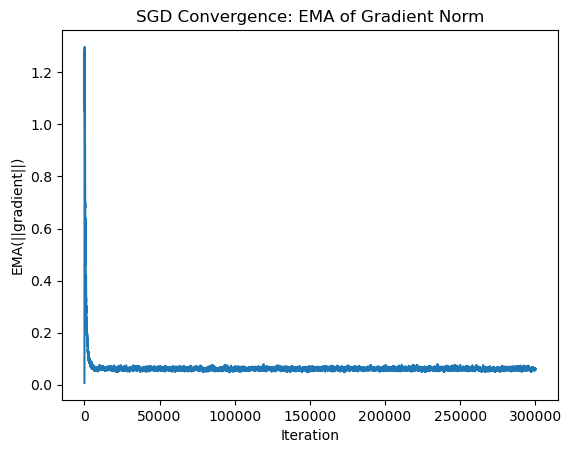

In [75]:
plt.figure()
plt.plot(ema_history)
plt.xlabel("Iteration")
plt.ylabel("EMA(||gradient||)")
plt.title("SGD Convergence: EMA of Gradient Norm")
plt.show()

The convergence plot displays the exponential moving average (EMA) of the gradient norm across iterations.

At the beginning of the optimisation process, the gradient norm is relatively large, reflecting substantial parameter adjustments as the model moves toward the minimum of the loss function. The sharp initial decline indicates rapid learning during early iterations.

After this early phase, the EMA stabilises at a low and relatively flat level. This behaviour suggests that:

- The algorithm has moved close to the minimum of the objective function.
- Parameter updates become small and oscillatory rather than directional.
- The optimisation process has reached a stable region of the parameter space.

The absence of large spikes after the initial phase indicates that the learning rate decay and gradient smoothing mechanisms effectively control stochastic noise. Overall, the plot confirms stable convergence behaviour consistent with the small coefficient differences observed relative to the Normal Equation benchmark.

### Step 6: Visual comparison of coefficients (SGD vs Normal Equation)

We visualise estimated coefficients from SGD and the Normal Equation side-by-side to confirm that SGD recovers the same economic exposures (factor loadings) as the deterministic OLS benchmark.

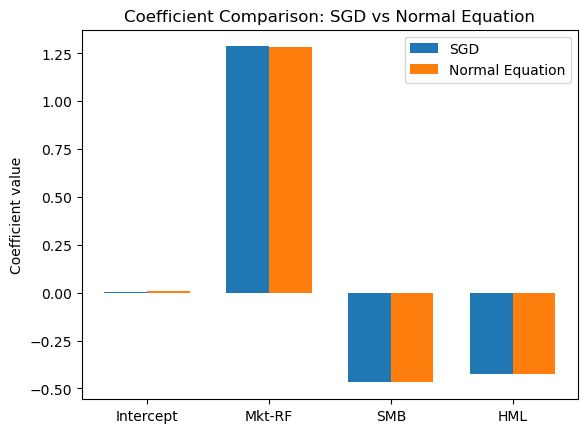

In [76]:
labels = ["Intercept", "Mkt-RF", "SMB", "HML"]

x = np.arange(len(labels))
width = 0.35

plt.figure()
plt.bar(x - width/2, beta_sgd, width, label="SGD")
plt.bar(x + width/2, beta_ne, width, label="Normal Equation")
plt.xticks(x, labels)
plt.ylabel("Coefficient value")
plt.title("Coefficient Comparison: SGD vs Normal Equation")
plt.legend()
plt.show()

The bar chart compares coefficient estimates obtained via stochastic gradient descent (SGD) with those from the closed-form OLS solution (Normal Equation).

The visual alignment between the two sets of coefficients is very close across all parameters:

- The **market beta (Mkt-RF)** is nearly identical between the two methods, indicating that SGD accurately captures the portfolio’s systematic market exposure.
- The **SMB and HML loadings** are also closely matched, confirming that size and value factor sensitivities are consistently estimated.
- The **intercept (alpha)** remains small and comparable across both methods, suggesting minimal unexplained excess return.

The small visual differences are consistent with the previously reported maximum absolute coefficient difference (≈ 0.00465). Such discrepancies are expected due to the stochastic nature of SGD and its tolerance-based convergence criterion.

Overall, the graphical comparison supports the numerical evidence that the implemented SGD procedure successfully recovers the OLS benchmark solution with high accuracy.

## Overall Interpretation

This section implemented stochastic gradient descent (SGD) to estimate the Fama–French three-factor regression model and benchmarked the results against the closed-form OLS solution obtained using the Normal Equation.

The optimisation process followed these key steps:

1. Predictors were standardised to improve numerical stability.
2. An intercept term was included explicitly.
3. SGD was run with a decaying learning rate schedule.
4. Convergence was monitored using the exponential moving average (EMA) of the gradient norm.
5. A burn-in period and tail averaging were applied to reduce variance in the final parameter estimates.
6. Final coefficients were converted back to the original predictor scale for comparison.

The algorithm ran for **300,000 iterations**, indicating that convergence was achieved after sustained stabilisation of gradient magnitudes.  
The convergence plot shows a rapid initial decline in the EMA of the gradient norm, followed by a stable low plateau, confirming that the optimisation process reached a steady region near the minimum.

When comparing coefficient estimates:

- The maximum absolute difference between SGD and the Normal Equation was **approximately 0.00465**.
- All coefficients (intercept, Mkt-RF, SMB, and HML) were very closely aligned.
- The economic interpretation of factor loadings remained identical across both methods.

These small differences are expected due to the stochastic nature of SGD and its tolerance-based stopping rule. However, the magnitude of the discrepancy is negligible relative to the coefficient sizes (e.g., market beta ≈ 1.28), confirming that SGD successfully approximates the deterministic OLS benchmark.

Overall, the results demonstrate that the implemented SGD procedure provides a stable, accurate, and computationally reliable numerical alternative to the closed-form regression solution.